In [1]:
import numpy as np
import scipy as sp
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
temp = []
visc = []
with open("oil_viscosity1000_temp.txt",'r') as f:
    for line in f:
        t, v = line.strip().split(' ')
        temp.append(float(t))
        visc.append(float(v))


temp = np.array(temp)
visc = np.array(visc)
print(temp)
print(visc)


[ 6.5  7.1 10.  10.8 11.6 13.3 16.9 20.7 21.4]
[1.24 1.22 1.14 1.12 1.1  1.06 0.99 0.92 0.91]


In [3]:
def fit_func(x, a, b):
    return a*np.exp(b*x)

def fit_func_poly(x, a, b, c, d):
    return a + b*x + c*x**2 + d*x**3

In [4]:
popt, pcov = curve_fit(fit_func_poly, temp, visc)
print(*popt)

1.4880868197404873 -0.0458071826831107 0.0012874481135148276 -1.920429401807994e-05


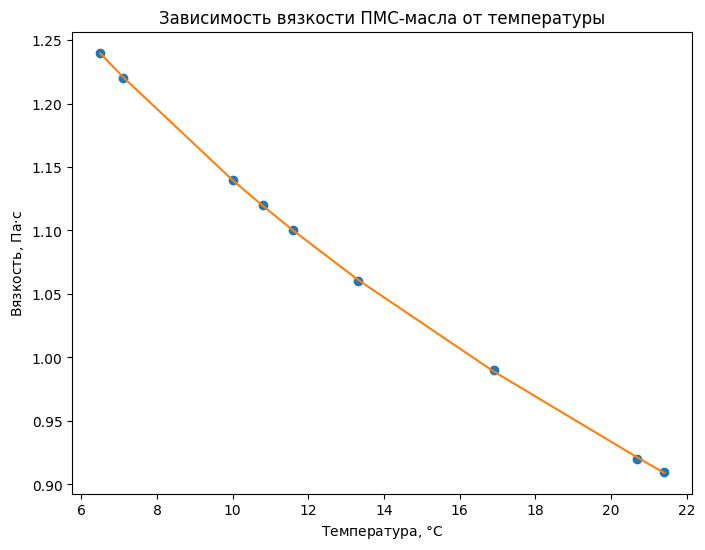

In [12]:
plt.figure(figsize=(8,6))

plt.plot(temp, visc, 'o')
plt.plot(temp, fit_func_poly(temp, *popt), '-')

plt.title('Зависимость вязкости ПМС-масла от температуры')
plt.xlabel(r'Температура, $\degree$C')
plt.ylabel(r'Вязкость, Па$\cdot$с')

plt.savefig('oil_viscosity.jpg')
plt.show()